🔹 Step 1 — Install & Import Required Libraries

In [1]:

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


🔹 Step 2 — Load Dataset

In [2]:
df = pd.read_csv("/content/Food_Delivery_Times.csv")

print("Dataset Preview:")
display(df.head())

print("\nDataset Info:")
print(df.info())

print("\nColumn Names:")
print(df.columns)


Dataset Preview:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None

Column Names:
Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')


🔹 Step 3 — Data Preprocessing

In [3]:
# Convert categorical columns to numeric
df = pd.get_dummies(df, drop_first=True)

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Fill missing values
df = df.fillna(df.mean())

print("Preprocessing Completed")


Missing Values:
 Order_ID                   0
Distance_km                0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
Weather_Foggy              0
Weather_Rainy              0
Weather_Snowy              0
Weather_Windy              0
Traffic_Level_Low          0
Traffic_Level_Medium       0
Time_of_Day_Evening        0
Time_of_Day_Morning        0
Time_of_Day_Night          0
Vehicle_Type_Car           0
Vehicle_Type_Scooter       0
dtype: int64
Preprocessing Completed


🔹 Step 4 — Define Features (X) and Target (y)

In [4]:
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 15)
Target Shape: (1000,)


🔹 Step 5 — Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (800, 15)
Testing Shape: (200, 15)


🔹 Step 6 — Train Linear Regression Model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed")


Model Training Completed


🔹 Step 7 — Prediction

In [7]:
y_pred = model.predict(X_test)

print("Sample Predictions:")
print(y_pred[:5])


Sample Predictions:
[35.07287921 71.94484172 43.96933503 44.12100725 79.52234671]


🔹 Step 8 — Model Evaluation

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance
MAE: 5.9993339190625115
RMSE: 8.934142248682162
R2 Score: 0.8219230386129983


🔹 Step 9 — Graph: Actual vs Predicted

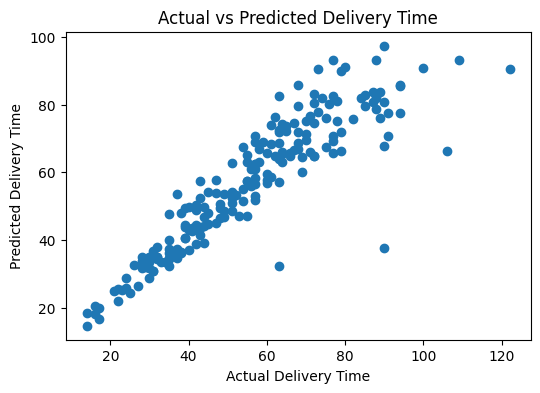

In [9]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()


🔹 Step 10 — Graph: Error Distribution

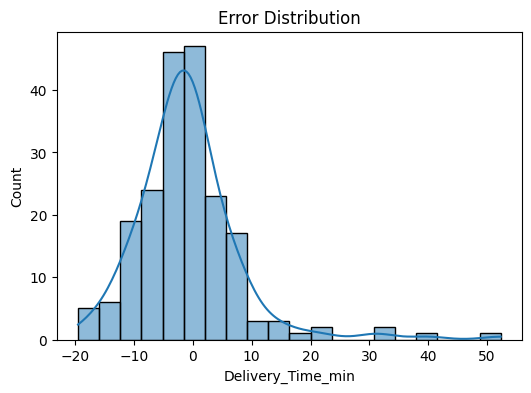

In [10]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, bins=20, kde=True)
plt.title("Error Distribution")
plt.show()


🔹 Step 11 — Predict Delivery Time for New Input

In [11]:
print("Predict Delivery Time for Sample Data")

sample = X.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Delivery Time:", prediction[0])


Predict Delivery Time for Sample Data
Predicted Delivery Time: 42.0448563010451
